## __Data Science: Capstone Part 1: Lightning Talk 1__

### Overview

In the field of data science, good projects are practical. Your capstone project should be manageable and affect a real world audience. This might be a domain you are familiar with, a particular interest you have, something that affects a community you are involved in, or an area that relates to a field you wish to work in.

One of the best ways to test ideas quickly is to share them with others. A good data scientist has to be comfortable discussing ideas and presenting to audiences. That's why for Part 1 of your Capstone project, you'll be preparing a lightning talk on some potential interest areas and datasets.

### REQUIRED

__For each Topic__:
- Problem Statement
- Goals
- Approach
- Data Source(s)
- Data Info. (basic EDA)

Dataset should have __15k+__ rows and __10+__ columns

___Remember, if you can't find data to support your topic, then you can't move forward.___

| # | Topic | Dataset |
|---|---|---|
| 1 | 🚗 Predicting Vehicle Accident Severity | US Accidents (Kaggle) |
| 2 | 🍎 Food / Nutrition Classification | Global Food & Nutrition Database 2026 (Kaggle) |
| 3 | 📱 Customer Churn Prediction | Customer Churn Prediction Dataset 1M (Kaggle) |

---
# 🚗 Topic 1: Predicting Vehicle Accident Severity

**File:** `US_Accidents.csv` &nbsp;|&nbsp; **Target column:** `Severity`

**Source:** [US Accidents Dataset (Kaggle)](https://www.kaggle.com/datasets/sobhanmoosavi/us-accidents)

**Problem Statement**
Traffic accidents in the US vary widely in severity, from minor delays to fatal multi-car incidents. Emergency responders, insurers, and city planners need a reliable way to anticipate how severe an accident is likely to be given the conditions it occurs under.

**Goals**
Build a classification model that predicts accident `Severity` (1-4) from road, weather, time-of-day, and location features, and identify which factors are most associated with higher-severity accidents.

**Approach**
1. Explore the raw accident records (this notebook — basic EDA only).
2. Engineer features from `Start_Time`/`End_Time` (hour, day of week, duration) and weather columns during full EDA/modeling phase.
3. Train baseline (Logistic Regression) and tree-based models (Random Forest / XGBoost) on the multi-class target.
4. Evaluate with macro F1 / confusion matrix, since `Severity` classes are imbalanced.

**Data Source(s)**
US Accidents (Kaggle) — nationwide car accident dataset covering 49 US states, ~7.7M rows and 46 columns (location, time, weather, and road-feature attributes). Meets the 15k+ rows / 10+ columns requirement.

**Data Info (basic EDA)**
See sections below for shape, dtypes, missingness, duplicates, correlation, outliers, and target distribution.

### 📖 Data Dictionary — Topic 1

| Column | Type | Description |
|---|---|---|
| `ID` | string | Unique identifier for the accident record |
|`Source`|string | Source of raw accident data|
| `Severity` | int (1-4) | **Target.** Impact on traffic (1 = least, 4 = most severe) |
| `Start_Time` / `End_Time` | datetime | When the accident began / traffic impact cleared |
| `Start_Lat` / `Start_Lng` | float | GPS coordinates of the accident |
| `End_Lat` / `End_Lng` | float | Shows latitude \longitude in GPS coordinate of the end point.|
| `Distance(mi)` | float | Length of road affected by the accident |
| `Description` | string | Free-text human-written description of the accident |
| `Street` / `City` / `County` / `State` / `Zipcode`/ `Country`/ `Timezone ` | string | Location fields |
|`Airport_Code`| string|Denotes an airport-based weather station which is the closest one to location of the accident|
| `Temperature(F)`, `Humidity(%)`, `Pressure(in)`, `Visibility(mi)` | float | Weather conditions at the time |
| `Wind_Direction`, `Wind_Speed(mph)`, `Precipitation(in)`, `Weather_Condition` | mixed | Additional weather conditions |
| `Amenity`, `Bump`, `Crossing`, `Give_Way`, `Junction`, `No_Exit`, `Railway`, `Roundabout`, `Station`, `Stop`, `Traffic_Calming`, `Traffic_Signal` | bool | Nearby road features (POIs) |
| `Sunrise_Sunset` | string | Whether it was day or night |

## 1. Load Data & Raw Shape

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df1 = pd.read_csv("./data/US_Accidents.csv")
print("Rows and Columns:", df1.shape)

Rows and Columns: (7728394, 46)


In [2]:
df1.head()

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.01,...,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.01,...,False,False,False,False,True,False,Day,Day,Day,Day


## 2. Data Types (`info()`)

In [3]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 7728394 entries, 0 to 7728393
Data columns (total 46 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   ID                     str    
 1   Source                 str    
 2   Severity               int64  
 3   Start_Time             str    
 4   End_Time               str    
 5   Start_Lat              float64
 6   Start_Lng              float64
 7   End_Lat                float64
 8   End_Lng                float64
 9   Distance(mi)           float64
 10  Description            str    
 11  Street                 str    
 12  City                   str    
 13  County                 str    
 14  State                  str    
 15  Zipcode                str    
 16  Country                str    
 17  Timezone               str    
 18  Airport_Code           str    
 19  Weather_Timestamp      str    
 20  Temperature(F)         float64
 21  Wind_Chill(F)          float64
 22  Humidity(%)            float6

## 3. Descriptive Statistics (`describe()`)
Numerical summary first, then categorical summary.

In [4]:
# Numerical columns summary
df1.describe()

,Severity,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
count,7.728394e+06,7.728394e+06,7.728394e+06,4.325632e+06,4.325632e+06,7.728394e+06,7.564541e+06,5.729375e+06,7.554250e+06,7.587715e+06,7.551296e+06,7.157161e+06,5.524808e+06
mean,2.212384e+00,3.620119e+01,-9.470255e+01,3.626183e+01,-9.572557e+01,5.618423e-01,6.166329e+01,5.825105e+01,6.483104e+01,2.953899e+01,9.090376e+00,7.685490e+00,8.407210e-03
std,4.875313e-01,5.076079e+00,1.739176e+01,5.272905e+00,1.810793e+01,1.776811e+00,1.901365e+01,2.238983e+01,2.282097e+01,1.006190e+00,2.688316e+00,5.424983e+00,1.102246e-01
min,1.000000e+00,2.455480e+01,-1.246238e+02,2.456601e+01,-1.245457e+02,0.000000e+00,-8.900000e+01,-8.900000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.000000e+00,3.339963e+01,-1.172194e+02,3.346207e+01,-1.177543e+02,0.000000e+00,4.900000e+01,4.300000e+01,4.800000e+01,2.937000e+01,1.000000e+01,4.600000e+00,0.000000e+00
50%,2.000000e+00,3.582397e+01,-8.776662e+01,3.618349e+01,-8.802789e+01,3.000000e-02,6.400000e+01,6.200000e+01,6.700000e+01,2.986000e+01,1.000000e+01,7.000000e+00,0.000000e+00
75%,2.000000e+00,4.008496e+01,-8.035368e+01,4.017892e+01,-8.024709e+01,4.640000e-01,7.600000e+01,7.500000e+01,8.400000e+01,3.003000e+01,1.000000e+01,1.040000e+01,0.000000e+00
max,4.000000e+00,4.900220e+01,-6.711317e+01,4.907500e+01,-6.710924e+01,4.417500e+02,2.070000e+02,2.070000e+02,1.000000e+02,5.863000e+01,1.400000e+02,1.087000e+03,3.647000e+01


In [5]:
# Categorical / object columns summary
df1.describe(include='string')

,ID,Source,Start_Time,End_Time,Description,Street,City,County,State,Zipcode,Country,Timezone,Airport_Code,Weather_Timestamp,Wind_Direction,Weather_Condition,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
count,7728394,7728394,7728394,7728394,7728389,7717525,7728141,7728394,7728394,7726479,7728394,7720586,7705759,7608166,7553188,7554935,7705148,7705148,7705148,7705148
unique,7728394,3,6131796,6705355,3761578,336306,13678,1871,49,825094,1,4,2045,941331,24,144,2,2,2,2
top,A-1,Source1,2021-01-26 16:16:13,2021-11-22 08:00:00,A crash has occurred causing no to minimum del...,I-95 N,Miami,Los Angeles,CA,91761,US,US/Eastern,KCQT,2022-03-13 01:53:00,CALM,Fair,Day,Day,Day,Day
freq,1,4325632,225,112,9593,78430,186917,526851,1741433,11247,7728394,3580167,118332,1311,961624,2560802,5334553,5695619,6076156,6377548


## 4. Target Column — `Severity`
**Q1: What is your target column and what does it represent?**

In [6]:
target_col_1 = "Severity" 

df1[target_col_1].value_counts(dropna=False)

Severity
2    6156981
3    1299337
4     204710
1      67366
Name: count, dtype: int64

**Answer (Q1):** `Severity` — a 1-4 integer code representing how much the accident impacted traffic flow (1 = shortest delay, 4 = most severe/longest delay). It is the label we want to predict.

**Q2: Is your target categorical or continuous? Is it balanced (plot the distribution)?**

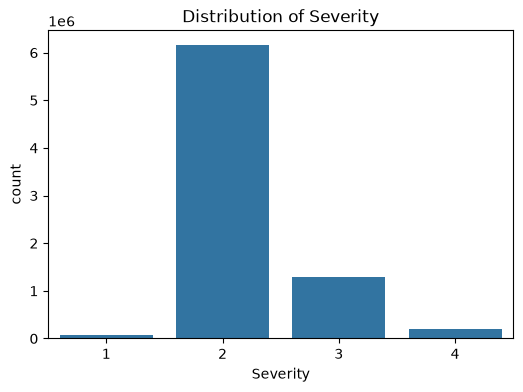

In [7]:
plt.figure(figsize=(6,4))
if df1[target_col_1].dtype == 'object' or df1[target_col_1].nunique() < 20:
    sns.countplot(x=target_col_1, data=df1)
else:
    sns.histplot(df1[target_col_1], kde=True)
plt.title(f"Distribution of {target_col_1}")
plt.show()

**Answer (Q2):** **Categorical (ordinal, 4 classes)** → this is a **classification** problem, not regression. It is **not balanced** — in the published US Accidents dataset, Severity 2 dominates (roughly 65-80% of records), Severity 3 is the next largest group, and Severity 1 and 4 are rare (often <5% combined). Confirm the exact split with the countplot above once you load the real file; plan to use macro-F1 / class weights / stratified sampling because of this imbalance.

## 5. Feature Types
**Q3: What types of features do you have (categorical / numerical)? How many of each?**

In [8]:
numeric_cols_1 = df1.select_dtypes(include=np.number).columns
categorical_cols_1 = df1.select_dtypes(include=['string']).columns

print("Numerical columns:", len(numeric_cols_1))
print("Categorical columns:", len(categorical_cols_1))

print("\nNumerical:", list(numeric_cols_1))
print("\nCategorical:", list(categorical_cols_1))

Numerical columns: 13
Categorical columns: 20

Numerical: ['Severity', 'Start_Lat', 'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)']

Categorical: ['ID', 'Source', 'Start_Time', 'End_Time', 'Description', 'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone', 'Airport_Code', 'Weather_Timestamp', 'Wind_Direction', 'Weather_Condition', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight']


**Answer (Q3):** Expect roughly a 60/40 split toward numerical vs. categorical: numerical features are the weather readings (`Temperature(F)`, `Humidity(%)`, `Pressure(in)`, `Visibility(mi)`, `Wind_Speed(mph)`, `Precipitation(in)`), GPS coordinates, and `Distance(mi)`; categorical/boolean features are the location fields (`City`, `County`, `State`, `Weather_Condition`) and the ~13 road-feature POI flags (`Crossing`, `Junction`, `Traffic_Signal`, etc.). Run the cell above to get the exact counts for your downloaded file.

## 6. Missing Values
**Q4: How many null values does each feature have? What's your plan for each?**

In [9]:
missing_1 = df1.isnull().sum()
missing_percentage_1 = (missing_1 / len(df1)) * 100

missing_table_1 = pd.DataFrame({
    "Missing Values": missing_1,
    "Percentage": missing_percentage_1
})

missing_table_1.sort_values(by="Missing Values", ascending=False).head(20)

,Missing Values,Percentage
End_Lng,3402762,44.029355
End_Lat,3402762,44.029355
Precipitation(in),2203586,28.512858
Wind_Chill(F),1999019,25.865904
Wind_Speed(mph),571233,7.391355
Visibility(mi),177098,2.291524
Wind_Direction,175206,2.267043
Humidity(%),174144,2.253301
Weather_Condition,173459,2.244438
Temperature(F),163853,2.120143


In [10]:
dup_count_1 = df1.duplicated().sum()
print("Duplicate rows:", dup_count_1)

Duplicate rows: 0


**Answer (Q4):** Weather columns (`Wind_Chill(F)`, `Precipitation(in)`, `Wind_Speed(mph)`) typically carry the most missing values in this dataset (can be 10-40%+ missing depending on the station). Plan: impute weather numerics with the median (or a location/time-based average) since dropping rows would lose a large share of data; drop only columns that are missing above ~50% (e.g. sometimes `Number`/`End_Lat`/`End_Lng` in older versions); location/ID fields have near-zero missingness and don't need any action.

## 7. Correlation
**Q5: Which features are most correlated with your target, and with each other?**

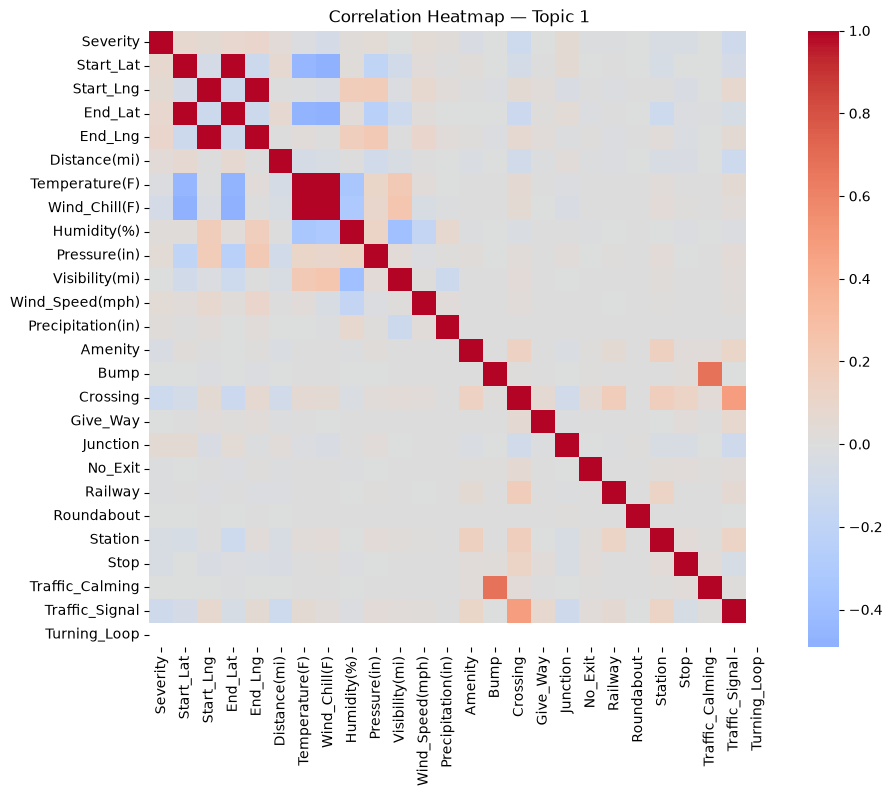

,Severity,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),...,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop
Severity,1.000000,0.069060,0.052862,0.083724,0.093190,0.034787,-0.020327,-0.070039,0.022293,0.042347,...,-0.004785,0.049890,-0.010352,-0.010303,-0.001678,-0.046032,-0.047106,-0.005502,-0.104901,NaN
Start_Lat,0.069060,1.000000,-0.067720,0.999993,-0.121743,0.064064,-0.443781,-0.480296,0.022364,-0.194094,...,0.002809,0.046600,-0.005312,0.002275,-0.001319,-0.050590,-0.003715,-0.004552,-0.064792,NaN
Start_Lng,0.052862,-0.067720,1.000000,-0.121735,0.999999,0.007851,-0.010652,-0.031810,0.179500,0.193185,...,0.025186,-0.034262,0.007632,-0.016957,0.000037,0.006239,-0.031081,-0.002103,0.070862,NaN
End_Lat,0.083724,0.999993,-0.121735,1.000000,-0.121732,0.067932,-0.468692,-0.489578,0.027849,-0.242143,...,0.012879,0.041223,-0.013982,0.002649,-0.002691,-0.110062,-0.013911,-0.010930,-0.047481,NaN
End_Lng,0.093190,-0.121743,0.999999,-0.121732,1.000000,0.005876,0.024084,0.006733,0.167428,0.216028,...,0.026358,-0.009776,0.012800,-0.012571,-0.000036,0.026145,-0.028812,-0.002327,0.052820,NaN
Distance(mi),0.034787,0.064064,0.007851,0.067932,0.005876,1.000000,-0.054082,-0.044309,0.008780,-0.093121,...,-0.009644,0.030164,-0.009509,-0.017251,-0.001439,-0.039792,-0.031564,-0.006047,-0.107457,NaN
Temperature(F),-0.020327,-0.443781,-0.010652,-0.468692,0.024084,-0.054082,1.000000,0.993744,-0.330939,0.109500,...,0.000694,-0.021417,0.007022,0.004571,0.000070,0.033638,0.008406,0.004947,0.047874,NaN
Wind_Chill(F),-0.070039,-0.480296,-0.031810,-0.489578,0.006733,-0.044309,0.993744,1.000000,-0.314731,0.086598,...,-0.002893,-0.030430,0.007955,0.005771,0.000255,0.039663,0.011614,0.006706,0.025507,NaN
Humidity(%),0.022293,0.022364,0.179500,0.027849,0.167428,0.008780,-0.330939,-0.314731,1.000000,0.115573,...,0.001534,0.000115,-0.008544,-0.001530,0.001115,-0.005542,-0.018117,-0.003507,-0.013867,NaN
Pressure(in),0.042347,-0.194094,0.193185,-0.242143,0.216028,-0.093121,0.109500,0.086598,0.115573,1.000000,...,0.007033,0.030465,-0.002753,0.014951,0.001279,0.036149,-0.006544,0.002045,0.039485,NaN


In [11]:
plt.figure(figsize=(10,8))
corr_1 = df1.corr(numeric_only=True)
sns.heatmap(corr_1, annot=False, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap — Topic 1")
plt.show()

corr_1

In [12]:
# Correlation with target
if pd.api.types.is_numeric_dtype(df1[target_col_1]):
    print(corr_1[target_col_1].sort_values(ascending=False))
else:
    # Target is categorical -> compare mean of each numeric feature across target groups
    display(df1.groupby(target_col_1)[numeric_cols_1].mean())

Severity             1.000000
End_Lng              0.093190
End_Lat              0.083724
Start_Lat            0.069060
Start_Lng            0.052862
Junction             0.049890
Pressure(in)         0.042347
Wind_Speed(mph)      0.040214
Distance(mi)         0.034787
Humidity(%)          0.022293
Precipitation(in)    0.021080
Roundabout          -0.001678
Visibility(mi)      -0.003473
Give_Way            -0.004785
Bump                -0.005158
Traffic_Calming     -0.005502
Railway             -0.010303
No_Exit             -0.010352
Temperature(F)      -0.020327
Amenity             -0.032875
Station             -0.046032
Stop                -0.047106
Wind_Chill(F)       -0.070039
Traffic_Signal      -0.104901
Crossing            -0.108323
Turning_Loop              NaN
Name: Severity, dtype: float64


**Answer (Q5):** Since `Severity` is categorical, correlation is assessed via the grouped-mean table (numeric feature averages per severity class) rather than a single Pearson coefficient. Expect weak-to-moderate signal from `Distance(mi)` (longer affected distance → higher severity) and from the road-feature flags (`Junction`, `Traffic_Signal`, `Crossing`) since intersections are associated with more severe accidents; weather variables (temperature, humidity, visibility) tend to correlate more weakly with severity but more strongly with each other (e.g. `Temperature(F)` and `Humidity(%)` are typically negatively correlated).

## 8. Outliers
**Q6: Are there outliers? How would you handle them?**

In [13]:
outlier_summary_1 = {}

for col in numeric_cols_1:
    Q1 = df1[col].quantile(0.25)
    Q3 = df1[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df1[col] < lower) | (df1[col] > upper)).sum()
    if n_outliers > 0:
        outlier_summary_1[col] = n_outliers

pd.DataFrame.from_dict(outlier_summary_1, orient='index', columns=['Outlier Count']).sort_values('Outlier Count', ascending=False)

,Outlier Count
Severity,1571413
Visibility(mi),1481065
Distance(mi),963606
Precipitation(in),533090
Pressure(in),443383
Wind_Speed(mph),210603
Temperature(F),50515
Wind_Chill(F),43869


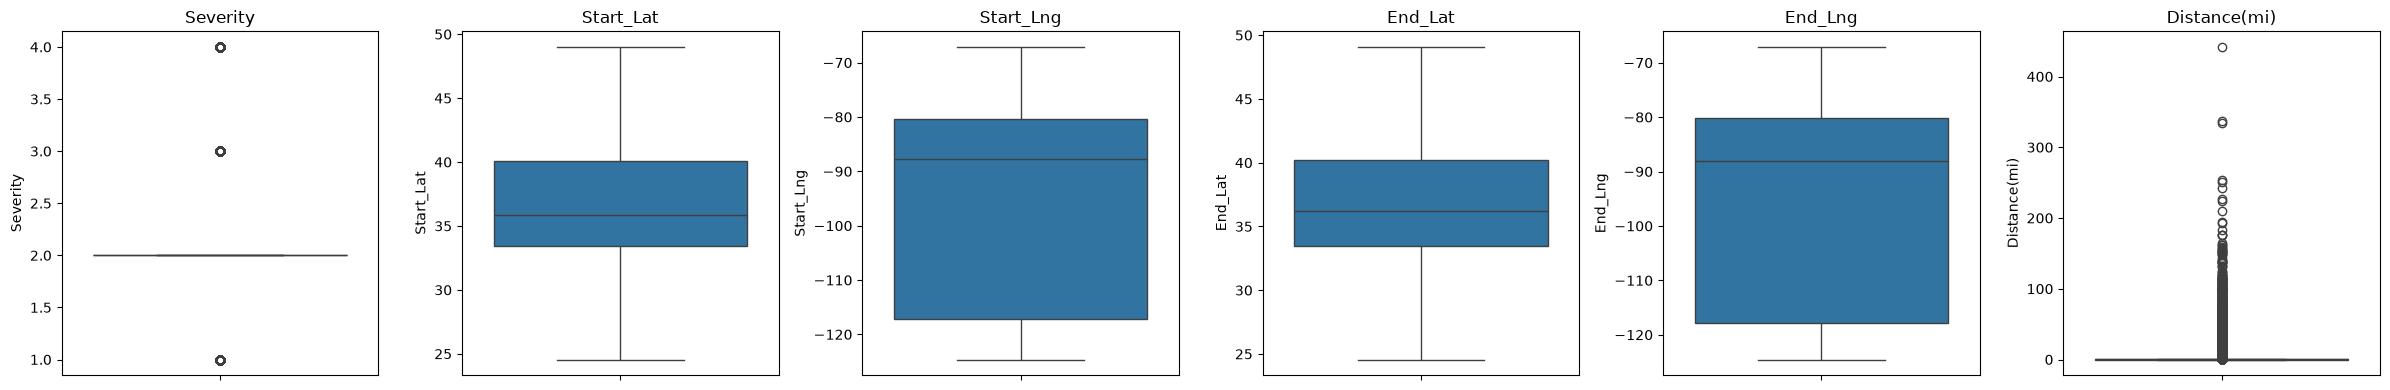

In [14]:
cols_to_plot_1 = list(numeric_cols_1)[:6]
if cols_to_plot_1:
    fig, axes = plt.subplots(1, len(cols_to_plot_1), figsize=(4*len(cols_to_plot_1), 4))
    if len(cols_to_plot_1) == 1:
        axes = [axes]
    for ax, col in zip(axes, cols_to_plot_1):
        sns.boxplot(y=df1[col], ax=ax)
        ax.set_title(col)
    plt.tight_layout()
    plt.show()

**Answer (Q6):** Yes — expect outliers in `Distance(mi)` (a small number of very long road-closure records) and in some weather fields (extreme temperature/pressure/visibility readings, sometimes sensor errors like negative visibility). Plan: keep outliers for `Distance(mi)` since long closures are legitimate/informative for severity, but cap or winsorize obviously erroneous weather readings (e.g. impossible temperature/pressure values) rather than deleting rows outright, to avoid losing data unnecessarily.

---
# 🍎 Topic 2: Food / Nutrition Classification

**File:** `comprehensive_foods_usda.csv` &nbsp;|&nbsp; **Target column:** `food_category`

**Source:** [Kaggle - Global Food and Nutrition Database 2026](https://www.kaggle.com/datasets/ahsanneural/global-food-and-nutrition-database-2026?select=comprehensive_foods_usda.csv)

**Problem Statement**
Nutrition and health-scoring apps need a way to automatically classify food items and flag their healthiness from raw nutrition-label data, which is often incomplete or inconsistently entered.

**Goals**
Build a classification model that predicts a food's `food_category` from its nutrition facts (calories, macros, micronutrients), supporting automatic tagging of new food entries.

**Approach**
1. Explore the raw nutrition data (this notebook — basic EDA only), paying attention to which fields are numeric nutrition facts vs. free text.
2. During full EDA/modeling: impute or drop missing nutrition values, normalize categorical text, and **exclude free-text fields** (`ingredients`, `food_name`) from the feature set so this stays a tabular/numeric classification project, not an NLP one.
3. Train a multi-class classifier (Random Forest / XGBoost / LightGBM) on the numeric nutrition features.
4. Evaluate with macro F1 across categories, checking for class imbalance.

**Data Source(s)**
Global Food & Nutrition Database 2026 (Kaggle) — food items with nutrition facts (calories, carbs, fat, protein, vitamins, minerals) and category/brand metadata. Confirm the exact row/column count meets 15k+ rows / 10+ columns once downloaded.

**Data Info (basic EDA)**
See sections below for shape, dtypes, missingness, duplicates, correlation, outliers, and target distribution.

### 📖 Data Dictionary — Topic 2

| Column | Type | Description |
|---|---|---|
| `food_name` | string (free text) | Name of the food item |
| `food_category` | string | **Target.** Category/classification of the food |
| `brand_owner` / `brand_name` | string | Manufacturer / brand information |
| `ingredients` | string (free text) | Ingredient list — ⚠️ excluded from features (keeps this a tabular, not NLP, project) |
| `serving_size` / `serving_unit` / `household_serving` | mixed | Serving-size information |
| `calories` | float | Energy per serving (kcal) |
| `protein_g`, `fat_g`, `saturated_fat_g`, `carbs_g`, `fiber_g`, `sugar_g` | float | Macronutrients (grams) |
| `sodium_mg`, `cholesterol_mg`, `calcium_mg`, `iron_mg`, `vitamin_c_mg` | float | Micronutrients (mg) |
| `food_type` | string | Broad food type/grouping |

⚠️ **NLP/text rule check:** the assignment excludes NLP/text datasets. This dataset has structured numeric nutrition columns as the core features, with `ingredients`/`food_name` as free text that we simply won't use as model inputs — so it stays eligible as long as those two text columns are excluded from modeling.

## 1. Load Data & Raw Shape

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# NOTE: update filename/path to match your downloaded file
df2 = pd.read_csv("./data/comprehensive_foods_usda.csv")
print("Rows and Columns:", df2.shape)

Rows and Columns: (40000, 24)


In [16]:
df2.head()

,fdc_id,food_name,data_type,food_category,brand_owner,brand_name,ingredients,serving_size,serving_unit,household_serving,...,protein_g,saturated_fat_g,vitamin_c_mg,fiber_g,iron_mg,sodium_mg,sugar_g,cholesterol_mg,health_score,food_type
0,167782,"Abiyuch, raw",SR Legacy,Fruits and Fruit Juices,NaN,NaN,NaN,NaN,NaN,NaN,...,1.50,0.014,54.1,5.3,1.61,20.0,8.55,NaN,65,Fruits
1,171687,"Acerola juice, raw",SR Legacy,Fruits and Fruit Juices,NaN,NaN,NaN,NaN,NaN,NaN,...,0.40,0.068,1600.0,0.3,0.50,3.0,4.50,0.0,55,Fruits
2,171686,"Acerola, (west indian cherry), raw",SR Legacy,Fruits and Fruit Juices,NaN,NaN,NaN,NaN,NaN,NaN,...,0.40,0.068,1680.0,1.1,0.20,7.0,NaN,0.0,55,Fruits
3,168061,Acorn stew (Apache),SR Legacy,American Indian/Alaska Native Foods,NaN,NaN,NaN,NaN,NaN,NaN,...,6.81,1.280,0.0,0.7,1.00,130.0,0.34,20.0,50,Other
4,168992,"Agave, cooked (Southwest)",SR Legacy,American Indian/Alaska Native Foods,NaN,NaN,NaN,NaN,NaN,NaN,...,0.99,NaN,0.3,10.6,3.55,13.0,20.90,0.0,50,Other


## 2. Data Types (`info()`)

In [17]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   fdc_id             40000 non-null  int64  
 1   food_name          40000 non-null  str    
 2   data_type          40000 non-null  str    
 3   food_category      39954 non-null  str    
 4   brand_owner        31383 non-null  str    
 5   brand_name         30254 non-null  str    
 6   ingredients        31656 non-null  str    
 7   serving_size       31842 non-null  float64
 8   serving_unit       31842 non-null  str    
 9   household_serving  30790 non-null  str    
 10  calories           39538 non-null  float64
 11  carbs_g            39411 non-null  float64
 12  calcium_mg         34215 non-null  float64
 13  fat_g              39713 non-null  float64
 14  protein_g          39747 non-null  float64
 15  saturated_fat_g    35014 non-null  float64
 16  vitamin_c_mg       22940 non-null

## 3. Descriptive Statistics (`describe()`)
Numerical summary first, then categorical summary.

In [18]:
# Numerical columns summary
df2.describe()

,fdc_id,serving_size,calories,carbs_g,calcium_mg,fat_g,protein_g,saturated_fat_g,vitamin_c_mg,fiber_g,iron_mg,sodium_mg,sugar_g,cholesterol_mg,health_score
count,4.000000e+04,31842.000000,39538.000000,39411.000000,34215.000000,39713.000000,39747.000000,35014.000000,22940.000000,33725.000000,34250.000000,3.938300e+04,35739.000000,34158.000000,40000.000000
mean,1.793461e+06,92.563962,308.159861,28.420500,106.091172,12.118343,8.260691,4.451546,24.138259,2.568491,2.389289,1.067233e+03,13.262690,62.575833,48.887250
std,8.964022e+05,100.581765,392.575965,47.614576,1327.632746,19.140351,10.668951,7.387522,1419.157682,5.662308,60.647733,2.895701e+04,36.323827,2141.337343,9.850912
min,1.675120e+05,0.000000,0.000000,-0.705000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,20.000000
25%,1.459896e+06,28.000000,85.000000,3.570000,5.000000,0.000000,0.420000,0.000000,0.000000,0.000000,0.030000,1.600000e+01,0.000000,0.000000,40.000000
50%,2.094756e+06,55.000000,250.000000,15.600000,29.000000,4.550000,5.130000,1.670000,0.000000,1.000000,0.980000,1.430000e+02,4.520000,0.000000,50.000000
75%,2.469605e+06,118.000000,404.000000,51.800000,98.000000,17.600000,12.500000,6.077500,5.200000,3.300000,2.280000,4.810000e+02,16.700000,38.000000,55.000000
max,2.752382e+06,5055.000000,37600.000000,6160.000000,150000.000000,1170.000000,760.000000,300.000000,210000.000000,588.000000,8930.000000,4.690000e+06,5560.000000,214000.000000,75.000000


In [44]:
# Categorical / object columns summary
df2.describe(include='string')

,food_name,data_type,food_category,brand_owner,brand_name,ingredients,serving_unit,household_serving,food_type
count,40000,40000,39954,31383,30254,31656,31842,30790,40000
unique,30900,3,240,5559,7174,24696,8,4226,9
top,2% REDUCED FAT MILK,Branded,"Fruit & Vegetable Juice, Nectars & Fruit Drinks",Beaver Street Fisheries Inc.,AHOLD,"REDUCED FAT MILK, VITAMIN A PALMITATE, VITAMIN...",g,1 Tbsp,Other
freq,386,31842,1937,706,421,153,18531,1881,15521


## 4. Target Column — `food_category`
**Q1: What is your target column and what does it represent?**

In [20]:
target_col_2 = "food_category"  # <-- confirm this matches the real column name once loaded

df2[target_col_2].value_counts(dropna=False)

food_category
Fruit & Vegetable Juice, Nectars & Fruit Drinks    1937
Cheese                                             1303
Candy                                              1185
Breads & Buns                                      1011
Chocolate                                           994
                                                   ... 
Baking Needs                                          1
Children's Nutritional Supplements                    1
Fish Substitutes                                      1
Vegetables  Unprepared/Unprocessed (Frozen)           1
Snack Foods - Cereal Snacks                           1
Name: count, Length: 241, dtype: int64

**Answer (Q1):** `food_category` — the category/type of the food item (e.g. 'snack', 'beverage', 'dairy', 'produce'), assigned by the dataset's own labeling. It's the label a classifier would predict from the nutrition facts.

**Q2: Is your target categorical or continuous? Is it balanced (plot the distribution)?**

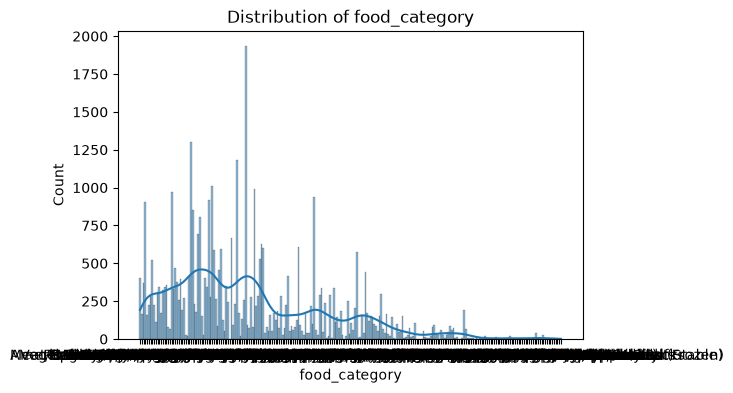

In [21]:
plt.figure(figsize=(6,4))
if df2[target_col_2].dtype == 'object' or df2[target_col_2].nunique() < 20:
    sns.countplot(x=target_col_2, data=df2)
else:
    sns.histplot(df2[target_col_2], kde=True)
plt.title(f"Distribution of {target_col_2}")
plt.show()

**Answer (Q2):** **Categorical (multi-class)** → this is a **classification** problem. Likely **not balanced** — common food/nutrition categories (e.g. 'snacks', 'beverages') tend to be over-represented relative to niche categories. Confirm the exact class counts with the countplot above; if a category has very few samples, consider grouping rare categories into an 'other' bucket for modeling.

## 5. Feature Types
**Q3: What types of features do you have (categorical / numerical)? How many of each?**

In [45]:
numeric_cols_2 = df2.select_dtypes(include=np.number).columns
categorical_cols_2 = df2.select_dtypes(include='string').columns

print("Numerical columns:", len(numeric_cols_2))
print("Categorical columns:", len(categorical_cols_2))

print("\nNumerical:", list(numeric_cols_2))
print("\nCategorical:", list(categorical_cols_2))

Numerical columns: 15
Categorical columns: 9

Numerical: ['fdc_id', 'serving_size', 'calories', 'carbs_g', 'calcium_mg', 'fat_g', 'protein_g', 'saturated_fat_g', 'vitamin_c_mg', 'fiber_g', 'iron_mg', 'sodium_mg', 'sugar_g', 'cholesterol_mg', 'health_score']

Categorical: ['food_name', 'data_type', 'food_category', 'brand_owner', 'brand_name', 'ingredients', 'serving_unit', 'household_serving', 'food_type']


**Answer (Q3):** Expect the numeric nutrition facts (`calories`, `protein_g`, `fat_g`, `saturated_fat_g`, `carbs_g`, `fiber_g`, `sugar_g`, `sodium_mg`, `cholesterol_mg`, `calcium_mg`, `iron_mg`, `vitamin_c_mg` — roughly 12 columns) to be the numerical block, and the categorical block to be `food_category`, `brand_owner`/`brand_name`, `serving_unit`, `household_serving`, `food_type`, plus the excluded free-text `food_name`/`ingredients`. Run the cell above for the exact counts.

## 6. Missing Values
**Q4: How many null values does each feature have? What's your plan for each?**

In [23]:
missing_2 = df2.isnull().sum()
missing_percentage_2 = (missing_2 / len(df2)) * 100

missing_table_2 = pd.DataFrame({
    "Missing Values": missing_2,
    "Percentage": missing_percentage_2
})

missing_table_2.sort_values(by="Missing Values", ascending=False).head(20)

,Missing Values,Percentage
vitamin_c_mg,17060,42.6500
brand_name,9746,24.3650
household_serving,9210,23.0250
brand_owner,8617,21.5425
ingredients,8344,20.8600
serving_unit,8158,20.3950
serving_size,8158,20.3950
fiber_g,6275,15.6875
cholesterol_mg,5842,14.6050
calcium_mg,5785,14.4625


In [24]:
dup_count_2 = df2.duplicated().sum()
print("Duplicate rows:", dup_count_2)

Duplicate rows: 0


**Answer (Q4):** Micronutrients (`vitamin_c_mg`, `iron_mg`, `calcium_mg`) are typically the most under-reported fields on nutrition labels and likely to show the highest missing %; `brand_owner`/`brand_name` may also be missing for generic/unbranded items. Plan: impute missing macro/micronutrient numerics with the median (or median-by-category, since nutrition varies a lot by food type); fill missing brand fields with 'unknown' rather than dropping rows, since brand isn't the target.

## 7. Correlation
**Q5: Which features are most correlated with your target, and with each other?**

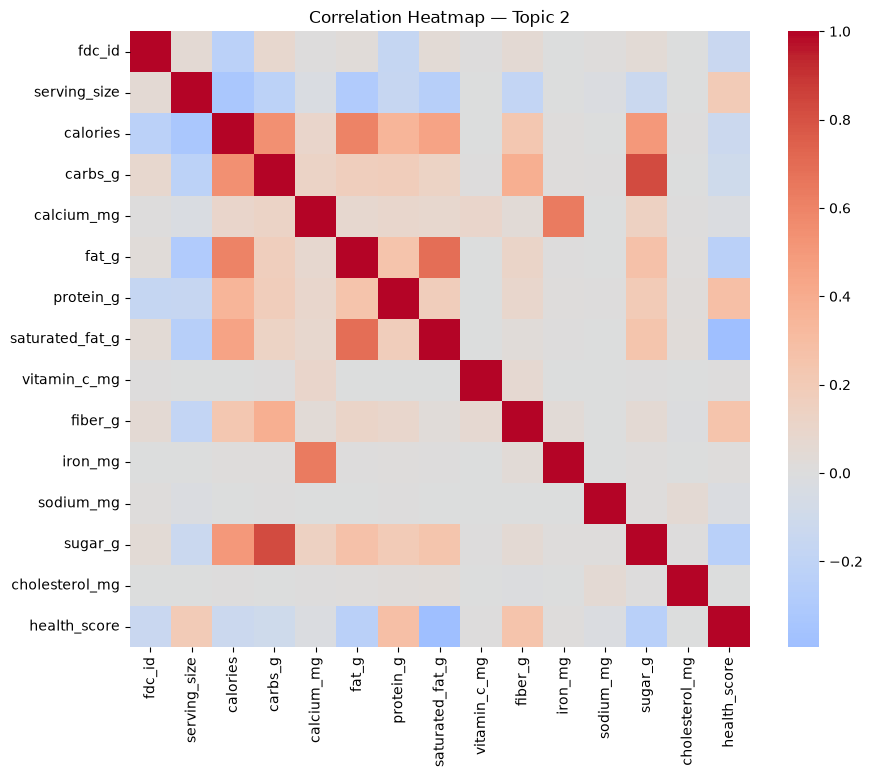

,fdc_id,serving_size,calories,carbs_g,calcium_mg,fat_g,protein_g,saturated_fat_g,vitamin_c_mg,fiber_g,iron_mg,sodium_mg,sugar_g,cholesterol_mg,health_score
fdc_id,1.000000,0.051794,-0.229005,0.082482,0.006100,0.025530,-0.160497,0.042040,0.008302,0.050680,-0.007199,0.011675,0.044580,0.002651,-0.143375
serving_size,0.051794,1.000000,-0.330011,-0.216901,-0.025529,-0.292358,-0.157598,-0.249475,-0.000810,-0.185995,-0.006999,-0.021844,-0.134281,-0.005716,0.194922
calories,-0.229005,-0.330011,1.000000,0.544032,0.096668,0.604094,0.349241,0.445800,-0.002202,0.232765,0.012478,-0.004085,0.507169,0.007046,-0.125762
carbs_g,0.082482,-0.216901,0.544032,1.000000,0.118549,0.170787,0.178770,0.128764,0.006254,0.389129,0.011315,0.007723,0.823009,-0.004427,-0.104910
calcium_mg,0.006100,-0.025529,0.096668,0.118549,1.000000,0.078005,0.095218,0.082429,0.096048,0.035761,0.637595,0.002389,0.145508,0.003703,-0.017732
fat_g,0.025530,-0.292358,0.604094,0.170787,0.078005,1.000000,0.248483,0.692073,-0.007343,0.114847,0.007886,-0.005704,0.275131,0.018071,-0.240956
protein_g,-0.160497,-0.157598,0.349241,0.178770,0.095218,0.248483,1.000000,0.180647,-0.005796,0.093659,0.016718,0.005769,0.196024,0.023392,0.288998
saturated_fat_g,0.042040,-0.249475,0.445800,0.128764,0.082429,0.692073,0.180647,1.000000,-0.005498,0.028100,0.008149,-0.003712,0.243762,0.030338,-0.394539
vitamin_c_mg,0.008302,-0.000810,-0.002202,0.006254,0.096048,-0.007343,-0.005796,-0.005498,1.000000,0.071648,0.001924,-0.000503,0.003182,-0.002728,0.005817
fiber_g,0.050680,-0.185995,0.232765,0.389129,0.035761,0.114847,0.093659,0.028100,0.071648,1.000000,0.033214,-0.005227,0.053918,-0.010249,0.254939


In [25]:
plt.figure(figsize=(10,8))
corr_2 = df2.corr(numeric_only=True)
sns.heatmap(corr_2, annot=False, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap — Topic 2")
plt.show()

corr_2

In [26]:
# Correlation with target
if pd.api.types.is_numeric_dtype(df2[target_col_2]):
    print(corr_2[target_col_2].sort_values(ascending=False))
else:
    # Target is categorical -> compare mean of each numeric feature across target groups
    display(df2.groupby(target_col_2)[numeric_cols_2].mean())

,fdc_id,serving_size,calories,carbs_g,calcium_mg,fat_g,protein_g,saturated_fat_g,vitamin_c_mg,fiber_g,iron_mg,sodium_mg,sugar_g,cholesterol_mg,health_score
food_category,,,,,,,,,,,,,,,
Alcohol,2.295518e+06,100.674419,193.441860,32.768571,64.133333,1.187381,2.136429,1.478125,38.125000,1.934783,2.747143,1133.292683,31.351951,1.285714,45.465116
All Noodles,2.188026e+06,65.250000,356.000000,67.397800,30.061224,4.522200,13.626600,1.193800,0.542105,3.279592,2.718600,400.160000,3.309375,36.142857,58.800000
American Indian/Alaska Native Foods,1.685085e+05,NaN,553.472727,11.253758,70.256944,11.109091,15.994667,1.988570,12.646392,4.170588,4.998121,160.234234,2.699759,88.471429,56.363636
Aquatic Invertebrates/Fish/Shellfish/Seafood Combination,1.460537e+06,170.000000,118.000000,8.820000,31.000000,3.530000,12.400000,0.590000,5.900000,0.600000,0.850000,359.000000,1.760000,50.000000,60.000000
Baby Foods,1.716985e+05,NaN,384.243478,22.439188,146.663768,5.419391,4.063884,2.208931,27.617889,1.028571,4.384203,55.752907,12.248371,6.406349,51.985507
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Water,2.140184e+06,356.780899,2.459259,0.307273,11.909091,0.028587,0.228159,0.057391,23.073333,0.413333,0.881429,4.930147,0.724706,0.000000,50.161871
Weight Control,2.469961e+06,153.400000,275.000000,17.500000,87.250000,9.568000,29.300000,1.034000,92.700000,9.720000,6.464000,453.000000,1.774000,5.000000,62.000000
Wholesome Snacks,2.174067e+06,78.320536,181.464758,36.385809,19.192819,3.834018,1.157096,3.523735,25.733211,3.667182,0.732050,28.086623,20.472445,0.301736,49.683060


**Answer (Q5):** For the numeric-vs-numeric heatmap, expect strong positive correlation between `calories` and `fat_g`/`carbs_g`/`sugar_g` (energy is derived from macros) and between `saturated_fat_g` and `fat_g`. For the categorical target, the grouped-mean table should show categories like 'beverages' with low `fat_g`/high `sugar_g`, and 'snacks' with high `fat_g`/`sodium_mg` — i.e. macronutrient profile is expected to be the strongest signal for `food_category`.

## 8. Outliers
**Q6: Are there outliers? How would you handle them?**

In [27]:
outlier_summary_2 = {}

for col in numeric_cols_2:
    Q1 = df2[col].quantile(0.25)
    Q3 = df2[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df2[col] < lower) | (df2[col] > upper)).sum()
    if n_outliers > 0:
        outlier_summary_2[col] = n_outliers

pd.DataFrame.from_dict(outlier_summary_2, orient='index', columns=['Outlier Count']).sort_values('Outlier Count', ascending=False)

,Outlier Count
vitamin_c_mg,3953
sugar_g,3575
saturated_fat_g,2560
fiber_g,2536
calcium_mg,2482
sodium_mg,2424
fat_g,2017
cholesterol_mg,1806
calories,1536
iron_mg,1475


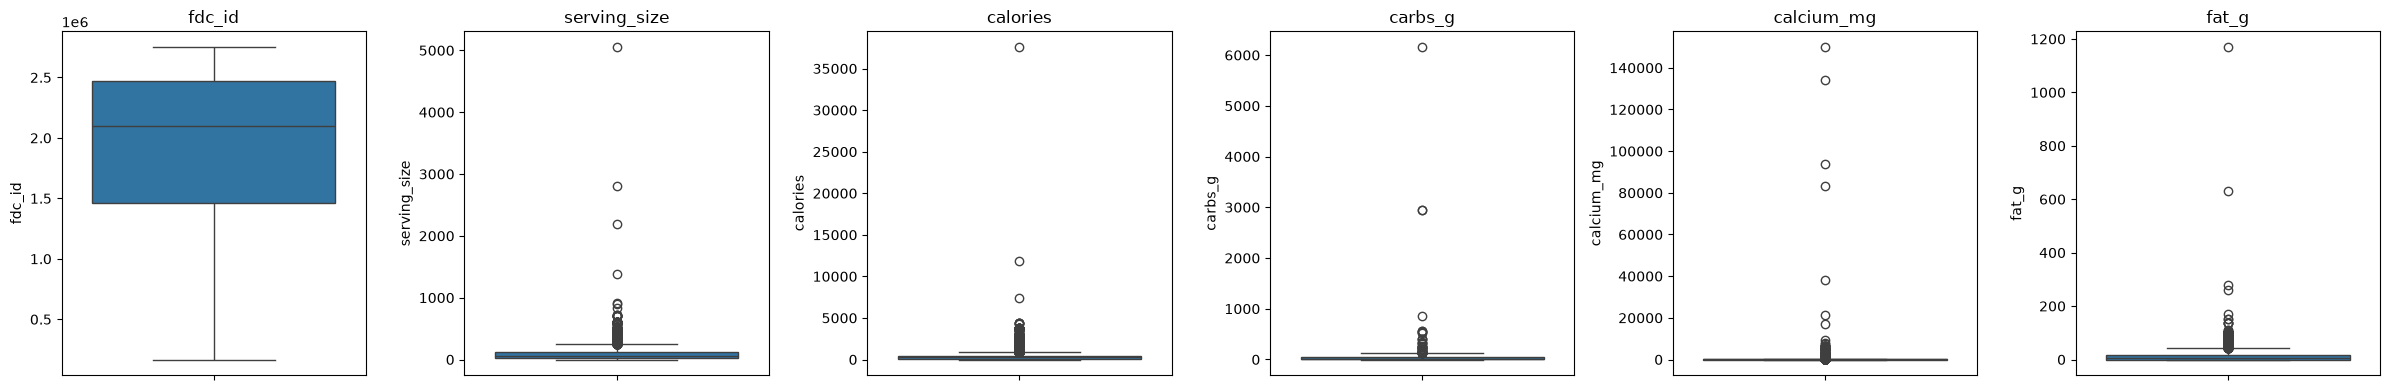

In [28]:
cols_to_plot_2 = list(numeric_cols_2)[:6]
if cols_to_plot_2:
    fig, axes = plt.subplots(1, len(cols_to_plot_2), figsize=(4*len(cols_to_plot_2), 4))
    if len(cols_to_plot_2) == 1:
        axes = [axes]
    for ax, col in zip(axes, cols_to_plot_2):
        sns.boxplot(y=df2[col], ax=ax)
        ax.set_title(col)
    plt.tight_layout()
    plt.show()

**Answer (Q6):** Yes — expect outliers in `calories`, `sodium_mg`, and `sugar_g` (a small number of extreme/energy-dense processed foods, or possible data-entry errors like calories per 100g vs. per serving mismatches). Plan: investigate a sample of the extreme rows first to confirm they're real (not unit-entry mistakes); cap true outliers using the IQR bounds shown above rather than dropping them, since genuinely energy-dense foods are valid and informative for classification.

---
# 📱 Topic 3: Customer Churn Prediction (1M rows)

**File:** `Customer_Churn_1M.csv` &nbsp;|&nbsp; **Target column:** `churn`

**Source:** [Customer Churn Prediction Dataset (1M Rows) - Kaggle](https://www.kaggle.com/datasets/isandeep06/customer-churn-prediction-dataset-1m)

**Problem Statement**
Subscription businesses lose recurring revenue when customers churn, and by the time a customer cancels it's too late to intervene — the company needs to know who is at risk *before* they leave.

**Goals**
Build a binary classifier that predicts customer `churn` from account, billing, and usage/support features, so retention teams can target at-risk customers proactively.

**Approach**
1. Explore the raw customer data (this notebook — basic EDA only).
2. During full EDA/modeling: engineer a `tenure` feature from `signup_date`, exclude `customer_id` (a unique identifier, not predictive) from the feature set.
3. Train a binary classifier (Logistic Regression baseline, then Random Forest / XGBoost).
4. Evaluate with precision/recall/F1 and ROC-AUC, since churn datasets are typically imbalanced.

**Data Source(s)**
Customer Churn Prediction Dataset (Kaggle) — ~1,000,000 rows of customer account, billing, and usage/support data with a binary churn label. Comfortably meets the 15k+ rows / 10+ columns requirement.

**Data Info (basic EDA)**
See sections below for shape, dtypes, missingness, duplicates, correlation, outliers, and target distribution.

### 📖 Data Dictionary — Topic 3

| Column | Type | Description |
|---|---|---|
| `customer_id` | string | Unique customer identifier (not predictive — excluded from modeling features) |
| `signup_date` | datetime | Date the customer signed up |
| `churn` | int/bool | **Target.** 1/Yes = customer churned, 0/No = retained |
| `annual_income` | float | Customer's annual income |
| `customer_satisfaction` | float | Satisfaction score (survey-based) |
| `avg_monthly_gb` | float | Average monthly data usage |
| `credit_score` | float | Customer credit score |
| `totalcharges` | float | Total amount billed to date |
| `num_complaints` | int | Number of support complaints logged |

*Additional columns (e.g. contract type, tenure, monthly charges) may exist in the real file — confirm and extend this table once loaded.*

## 1. Load Data & Raw Shape

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# NOTE: update filename/path to match your downloaded file
df3 = pd.read_csv("./data/Customer_Churn_1M.csv")
print("Rows and Columns:", df3.shape)

Rows and Columns: (1000000, 32)


In [30]:
df3.head()

,customer_id,signup_date,age,gender,annual_income,education,marital_status,dependents,tenure,contract,...,has_streaming_tv,has_streaming_movies,customer_satisfaction,num_complaints,num_service_calls,late_payments,avg_monthly_gb,days_since_last_interaction,credit_score,churn
0,CUST0000000001,2022-12-12 12:53:58.199463,43,Female,55085.25,college,married,1,2,two_year,...,1,1,9.0,0.0,0,0,109.63,16,NaN,0
1,CUST0000000002,2022-01-13 12:53:58.199973,18,Male,60786.11,master,married,1,22,one_year,...,0,1,7.0,0.0,3,1,63.25,134,585.0,0
2,CUST0000000003,2023-09-04 12:53:58.199985,38,Female,73184.32,high_school,widowed,0,3,two_year,...,1,0,6.0,1.0,1,0,47.77,11,632.0,0
3,CUST0000000004,2022-06-27 12:53:58.199992,44,Male,40923.78,high_school,married,1,6,two_year,...,0,1,5.0,2.0,2,1,50.82,6,569.0,0
4,CUST0000000005,2022-12-08 12:53:58.199999,45,Female,36400.94,bachelor,single,0,9,two_year,...,0,1,8.0,1.0,1,0,16.74,18,657.0,0


## 2. Data Types (`info()`)

In [31]:
df3.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 32 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   customer_id                  1000000 non-null  str    
 1   signup_date                  1000000 non-null  str    
 2   age                          1000000 non-null  int64  
 3   gender                       1000000 non-null  str    
 4   annual_income                970041 non-null   float64
 5   education                    1000000 non-null  str    
 6   marital_status               1000000 non-null  str    
 7   dependents                   1000000 non-null  int64  
 8   tenure                       1000000 non-null  int64  
 9   contract                     1000000 non-null  str    
 10  payment_method               1000000 non-null  str    
 11  paperless_billing            1000000 non-null  str    
 12  senior_citizen               1000000 non-null  int64  

## 3. Descriptive Statistics (`describe()`)
Numerical summary first, then categorical summary.

In [32]:
# Numerical columns summary
df3.describe()

,age,annual_income,dependents,tenure,senior_citizen,monthlycharges,totalcharges,num_services,has_phone_service,has_internet_service,...,has_streaming_tv,has_streaming_movies,customer_satisfaction,num_complaints,num_service_calls,late_payments,avg_monthly_gb,days_since_last_interaction,credit_score,churn
count,1000000.000000,970041.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,...,1000000.00000,1000000.000000,980079.000000,970094.000000,1000000.000000,1000000.000000,949988.000000,1000000.000000,959605.000000,1000000.000000
mean,44.724603,58788.311936,0.799831,22.381923,0.199511,86.443701,1837.321438,2.563721,0.769551,0.849742,...,0.59999,0.549086,6.159110,0.701667,1.760248,0.400969,39.095179,44.494191,678.562134,0.099227
std,14.479468,37137.433079,0.893654,20.073341,0.399633,27.592430,1803.721634,1.412330,0.421120,0.357324,...,0.48990,0.497585,2.328287,0.838148,1.485677,0.633289,43.852564,44.922587,87.642951,0.298967
min,18.000000,20000.000000,0.000000,1.000000,0.000000,20.000000,16.300000,1.000000,0.000000,0.000000,...,0.00000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,300.000000,0.000000
25%,34.000000,32712.560000,0.000000,6.000000,0.000000,70.490000,484.530000,1.000000,1.000000,1.000000,...,0.00000,0.000000,4.000000,0.000000,1.000000,0.000000,12.840000,12.000000,619.000000,0.000000
50%,44.000000,48954.600000,1.000000,16.000000,0.000000,85.480000,1249.750000,2.000000,1.000000,1.000000,...,1.00000,1.000000,7.000000,1.000000,1.000000,0.000000,27.770000,31.000000,680.000000,0.000000
75%,55.000000,73475.130000,1.000000,33.000000,0.000000,100.680000,2617.660000,3.000000,1.000000,1.000000,...,1.00000,1.000000,8.000000,1.000000,3.000000,1.000000,51.230000,62.000000,740.000000,0.000000
max,90.000000,250000.000000,5.000000,72.000000,1.000000,854.956730,16252.861508,6.000000,1.000000,1.000000,...,1.00000,1.000000,9.000000,7.000000,12.000000,5.000000,557.824023,365.000000,850.000000,1.000000


In [46]:
# Categorical / object columns summary
df3.describe(include='string')

,customer_id,signup_date,gender,education,marital_status,contract,payment_method,paperless_billing
count,1000000,1000000,1000000,1000000,1000000,1000000,1000000,1000000
unique,1000000,1000000,3,5,4,3,4,2
top,CUST0000000001,2022-12-12 12:53:58.199463,Male,bachelor,married,one_year,credit_card,Yes
freq,1,1,490166,300324,450115,550468,349706,749880


## 4. Target Column — `churn`
**Q1: What is your target column and what does it represent?**

In [34]:
target_col_3 = "churn"  # <-- confirm this matches the real column name once loaded

df3[target_col_3].value_counts(dropna=False)

churn
0    900773
1     99227
Name: count, dtype: int64

**Answer (Q1):** `churn` — a binary flag (1/Yes = churned, 0/No = retained) indicating whether the customer canceled their subscription/service. It's the label the retention model would predict.

**Q2: Is your target categorical or continuous? Is it balanced (plot the distribution)?**

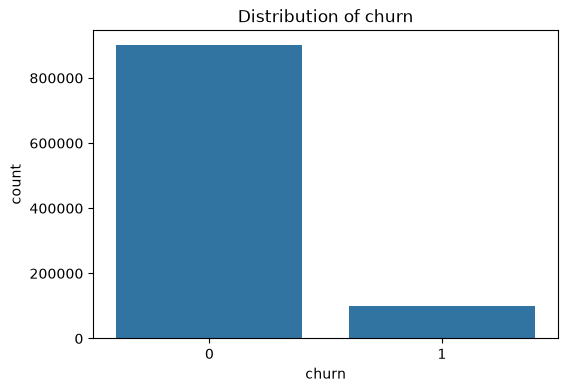

In [35]:
plt.figure(figsize=(6,4))
if df3[target_col_3].dtype == 'object' or df3[target_col_3].nunique() < 20:
    sns.countplot(x=target_col_3, data=df3)
else:
    sns.histplot(df3[target_col_3], kde=True)
plt.title(f"Distribution of {target_col_3}")
plt.show()

**Answer (Q2):** **Categorical (binary)** → this is a **classification** problem. Likely **not balanced** — churn datasets typically see the majority of customers retained (churn rate often somewhere in the 15-35% range for this kind of synthetic dataset). Confirm the exact split with the countplot above; plan to use class weights, stratified train/test splits, and precision/recall (not just accuracy) because of the imbalance.

## 5. Feature Types
**Q3: What types of features do you have (categorical / numerical)? How many of each?**

In [47]:
numeric_cols_3 = df3.select_dtypes(include=np.number).columns
categorical_cols_3 = df3.select_dtypes(include='string').columns

print("Numerical columns:", len(numeric_cols_3))
print("Categorical columns:", len(categorical_cols_3))

print("\nNumerical:", list(numeric_cols_3))
print("\nCategorical:", list(categorical_cols_3))

Numerical columns: 24
Categorical columns: 8

Numerical: ['age', 'annual_income', 'dependents', 'tenure', 'senior_citizen', 'monthlycharges', 'totalcharges', 'num_services', 'has_phone_service', 'has_internet_service', 'has_online_security', 'has_online_backup', 'has_device_protection', 'has_tech_support', 'has_streaming_tv', 'has_streaming_movies', 'customer_satisfaction', 'num_complaints', 'num_service_calls', 'late_payments', 'avg_monthly_gb', 'days_since_last_interaction', 'credit_score', 'churn']

Categorical: ['customer_id', 'signup_date', 'gender', 'education', 'marital_status', 'contract', 'payment_method', 'paperless_billing']


**Answer (Q3):** Expect a numerical block covering billing/usage/behavioral fields (`annual_income`, `customer_satisfaction`, `avg_monthly_gb`, `credit_score`, `totalcharges`, `num_complaints`, and the binary `churn` target itself) and a small categorical/identifier/date block (`customer_id`, `signup_date`, plus any contract-type or plan columns present in the real file). Run the cell above for exact counts.

## 6. Missing Values
**Q4: How many null values does each feature have? What's your plan for each?**

In [37]:
missing_3 = df3.isnull().sum()
missing_percentage_3 = (missing_3 / len(df3)) * 100

missing_table_3 = pd.DataFrame({
    "Missing Values": missing_3,
    "Percentage": missing_percentage_3
})

missing_table_3.sort_values(by="Missing Values", ascending=False).head(20)

,Missing Values,Percentage
avg_monthly_gb,50012,5.0012
credit_score,40395,4.0395
annual_income,29959,2.9959
num_complaints,29906,2.9906
customer_satisfaction,19921,1.9921
customer_id,0,0.0000
age,0,0.0000
signup_date,0,0.0000
tenure,0,0.0000
contract,0,0.0000


In [38]:
dup_count_3 = df3.duplicated().sum()
print("Duplicate rows:", dup_count_3)

Duplicate rows: 0


**Answer (Q4):** `totalcharges` is a common source of missing/blank values in churn datasets (often blank for brand-new customers with $0 billed so far); satisfaction/usage survey fields (`customer_satisfaction`) can also have gaps if not every customer responded. Plan: impute `totalcharges` and other numeric gaps with the median (or 0 where a blank genuinely means 'no charges yet'); `customer_id` and `churn` itself should have no missing values — if they do, those rows should be dropped since the target can't be imputed.

## 7. Correlation
**Q5: Which features are most correlated with your target, and with each other?**

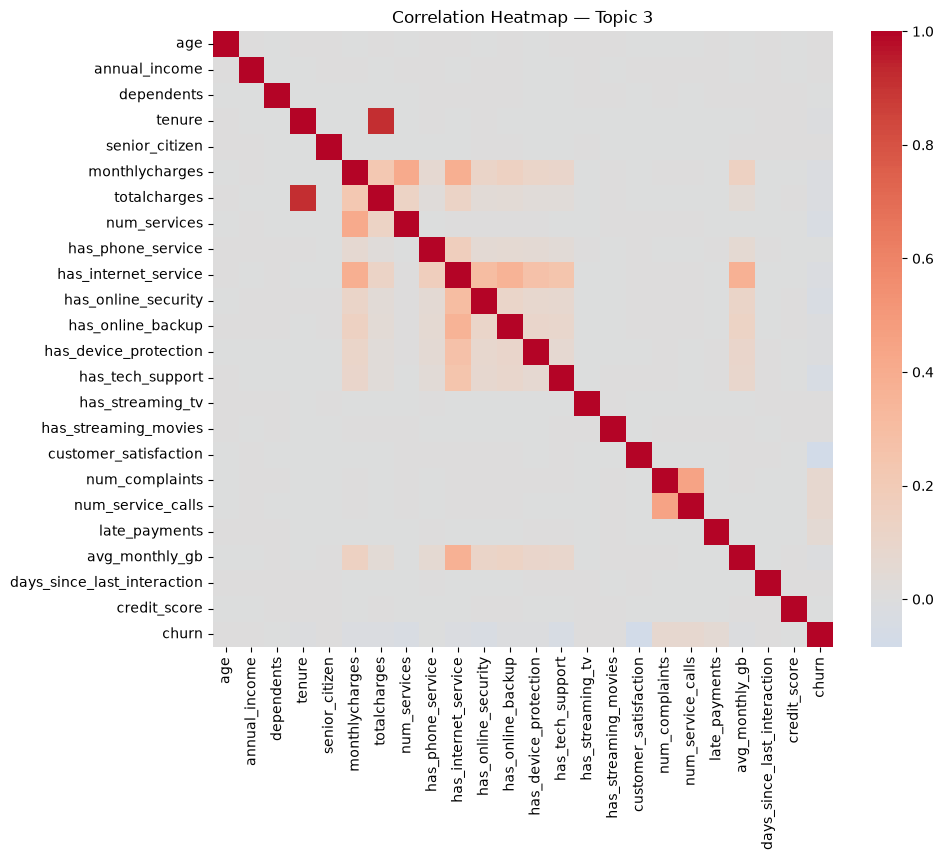

,age,annual_income,dependents,tenure,senior_citizen,monthlycharges,totalcharges,num_services,has_phone_service,has_internet_service,...,has_streaming_tv,has_streaming_movies,customer_satisfaction,num_complaints,num_service_calls,late_payments,avg_monthly_gb,days_since_last_interaction,credit_score,churn
age,1.000000,0.000807,-0.000254,0.001752,0.000435,-0.000574,0.001432,-0.000587,0.002293,0.000440,...,0.000987,0.000910,-0.001211,-0.000886,-0.001008,0.001538,-0.000139,0.000453,-0.000664,0.000264
annual_income,0.000807,1.000000,-0.000711,-0.000732,0.000878,0.001081,-0.000286,0.001629,0.002375,-0.000347,...,0.001088,-0.000775,0.001414,0.001505,0.000759,0.000003,-0.001068,0.000783,-0.000970,0.000466
dependents,-0.000254,-0.000711,1.000000,-0.001216,-0.000459,-0.002295,-0.001135,-0.000736,0.001117,0.000846,...,0.000780,0.001237,-0.002433,0.001686,-0.000727,0.002454,0.001243,0.001398,0.000143,-0.000145
tenure,0.001752,-0.000732,-0.001216,1.000000,-0.001340,-0.000631,0.912829,-0.001431,0.001282,-0.000082,...,-0.002728,-0.000473,-0.000633,-0.002449,-0.000716,-0.001073,-0.000866,0.000092,0.002538,-0.012709
senior_citizen,0.000435,0.000878,-0.000459,-0.001340,1.000000,-0.000347,-0.000820,-0.000488,-0.000023,-0.000384,...,0.001728,-0.001200,-0.000774,-0.000619,-0.000422,-0.000963,0.000195,0.001256,0.000466,0.000344
monthlycharges,-0.000574,0.001081,-0.002295,-0.000631,-0.000347,1.000000,0.224526,0.410663,0.066989,0.386898,...,-0.000863,0.001641,-0.000731,0.001802,0.000788,-0.000119,0.143499,-0.002576,-0.001425,-0.013849
totalcharges,0.001432,-0.000286,-0.001135,0.912829,-0.000820,0.224526,1.000000,0.132443,0.022820,0.126599,...,-0.002767,0.000198,-0.001421,-0.002005,-0.000401,-0.000897,0.045982,-0.000493,0.002439,-0.016501
num_services,-0.000587,0.001629,-0.000736,-0.001431,-0.000488,0.410663,0.132443,1.000000,-0.000568,0.000263,...,-0.001623,0.000626,0.000308,0.000917,0.001962,-0.000155,-0.000370,-0.001065,-0.000397,-0.033378
has_phone_service,0.002293,0.002375,0.001117,0.001282,-0.000023,0.066989,0.022820,-0.000568,1.000000,0.171257,...,0.003907,-0.000223,0.000231,-0.000071,-0.000629,0.000048,0.063088,0.000632,-0.000312,-0.002274
has_internet_service,0.000440,-0.000347,0.000846,-0.000082,-0.000384,0.386898,0.126599,0.000263,0.171257,1.000000,...,-0.001524,-0.000070,0.001202,0.001904,0.000434,-0.000567,0.371405,-0.001493,-0.000191,-0.015261


In [39]:
plt.figure(figsize=(10,8))
corr_3 = df3.corr(numeric_only=True)
sns.heatmap(corr_3, annot=False, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap — Topic 3")
plt.show()

corr_3

In [40]:
# Correlation with target
if pd.api.types.is_numeric_dtype(df3[target_col_3]):
    print(corr_3[target_col_3].sort_values(ascending=False))
else:
    # Target is categorical -> compare mean of each numeric feature across target groups
    display(df3.groupby(target_col_3)[numeric_cols_3].mean())

churn                          1.000000
num_complaints                 0.079985
num_service_calls              0.077284
late_payments                  0.047705
has_streaming_movies           0.001915
has_streaming_tv               0.000695
annual_income                  0.000466
days_since_last_interaction    0.000391
senior_citizen                 0.000344
age                            0.000264
dependents                    -0.000145
credit_score                  -0.000378
has_phone_service             -0.002274
has_device_protection         -0.004908
has_online_backup             -0.004919
avg_monthly_gb                -0.006144
tenure                        -0.012709
monthlycharges                -0.013849
has_internet_service          -0.015261
totalcharges                  -0.016501
num_services                  -0.033378
has_online_security           -0.034106
has_tech_support              -0.045477
customer_satisfaction         -0.084749
Name: churn, dtype: float64


**Answer (Q5):** Since `churn` is binary/categorical, the grouped-mean table (numeric feature averages for churned vs. retained customers) is the right correlation check here. Expect `customer_satisfaction` to be notably lower and `num_complaints` notably higher for churned customers; `totalcharges` and `annual_income` typically show weaker but still directionally meaningful differences. Among the numeric features themselves, `totalcharges` is usually correlated with tenure/usage (`avg_monthly_gb`) since both accumulate over time.

## 8. Outliers
**Q6: Are there outliers? How would you handle them?**

In [41]:
outlier_summary_3 = {}

for col in numeric_cols_3:
    Q1 = df3[col].quantile(0.25)
    Q3 = df3[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df3[col] < lower) | (df3[col] > upper)).sum()
    if n_outliers > 0:
        outlier_summary_3[col] = n_outliers

pd.DataFrame.from_dict(outlier_summary_3, orient='index', columns=['Outlier Count']).sort_values('Outlier Count', ascending=False)

,Outlier Count
has_phone_service,230449
senior_citizen,199511
has_internet_service,150258
churn,99227
avg_monthly_gb,56428
dependents,47406
days_since_last_interaction,47040
totalcharges,45654
annual_income,44871
num_complaints,33220


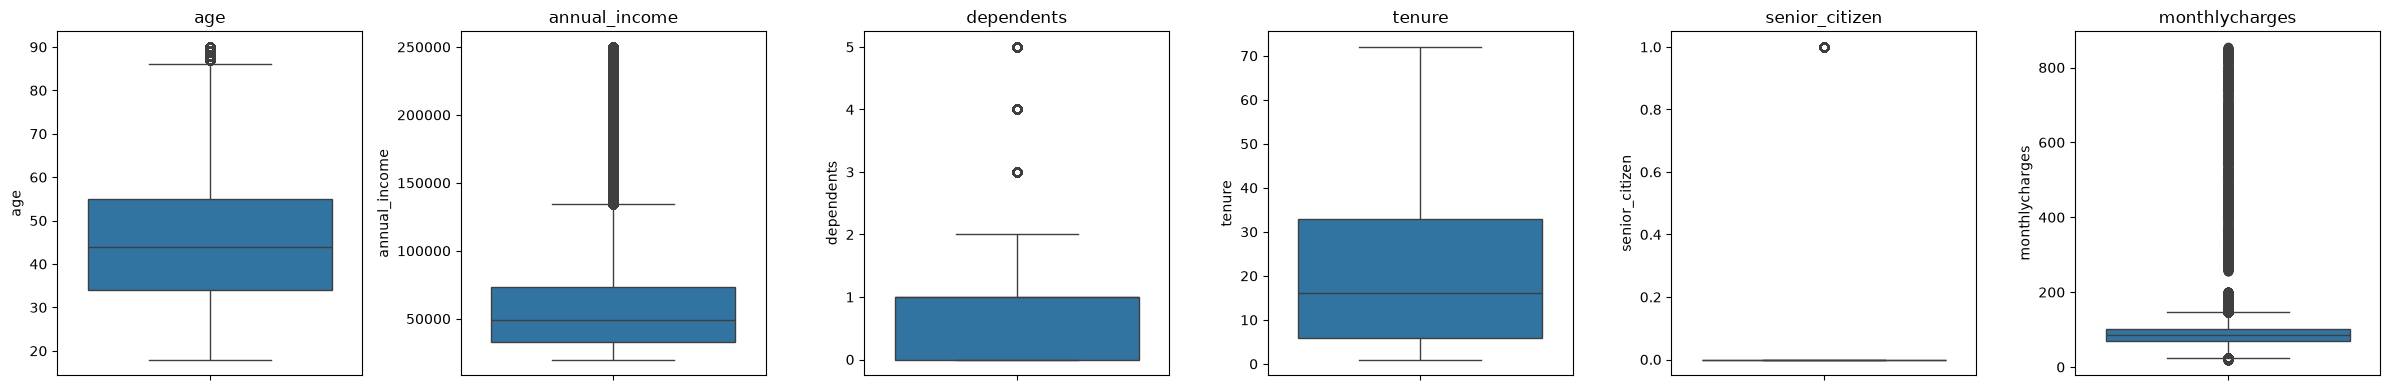

In [42]:
cols_to_plot_3 = list(numeric_cols_3)[:6]
if cols_to_plot_3:
    fig, axes = plt.subplots(1, len(cols_to_plot_3), figsize=(4*len(cols_to_plot_3), 4))
    if len(cols_to_plot_3) == 1:
        axes = [axes]
    for ax, col in zip(axes, cols_to_plot_3):
        sns.boxplot(y=df3[col], ax=ax)
        ax.set_title(col)
    plt.tight_layout()
    plt.show()

**Answer (Q6):** Yes — expect outliers in `totalcharges` (customers who've been on the platform a long time accumulate very high totals) and possibly `annual_income` (a few very high-income outliers). Plan: keep `totalcharges` outliers since they reflect real long-tenure customers and are informative; cap or investigate extreme `annual_income`/`credit_score` values for possible data-entry errors (e.g. income values that look like typos) before modeling.

---
# 📊 Cross-Topic Comparison

Fill this in after running each topic's cells on your real downloaded file — use it to help decide on the final topic for the Lightning Talk.

In [43]:
comparison = pd.DataFrame({
    "🚗 Accidents": {
        "Rows": df1.shape[0],
        "Columns": df1.shape[1],
        "Meets 15k+/10+ requirement?": "Yes" if (df1.shape[0] >= 15000 and df1.shape[1] >= 10) else "No",
        "Target column": "Severity",
        "Classification or Regression?": "Classification",
        "Duplicate rows": dup_count_1,
    },
    "🍎 Food/Nutrition": {
        "Rows": df2.shape[0],
        "Columns": df2.shape[1],
        "Meets 15k+/10+ requirement?": "Yes" if (df2.shape[0] >= 15000 and df2.shape[1] >= 10) else "No",
        "Target column": "food_category",
        "Classification or Regression?": "Classification",
        "Duplicate rows": dup_count_2,
    },
    "📱 Churn": {
        "Rows": df3.shape[0],
        "Columns": df3.shape[1],
        "Meets 15k+/10+ requirement?": "Yes" if (df3.shape[0] >= 15000 and df3.shape[1] >= 10) else "No",
        "Target column": "churn",
        "Classification or Regression?": "Classification",
        "Duplicate rows": dup_count_3,
    },
})

comparison

,🚗 Accidents,🍎 Food/Nutrition,📱 Churn
Rows,7728394,40000,1000000
Columns,46,24,32
Meets 15k+/10+ requirement?,Yes,Yes,Yes
Target column,Severity,food_category,churn
Classification or Regression?,Classification,Classification,Classification
Duplicate rows,0,0,0
